# Imports

In [46]:
import h5py
import numpy as np
import sys
import torch
import math

import torch
import torch.nn as nn
from torch.nn import TransformerEncoder, TransformerEncoderLayer
import torch.optim as optim
from sklearn.metrics import roc_auc_score
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt

In [2]:
# Loading and Splitting Datasets
h5_name = '4tops_splitted.h5'
hf = h5py.File(h5_name, 'r')
print(hf.keys())

X_train   = torch.tensor(np.array(hf.get('X_train')), dtype=torch.float32)
X_val     = torch.tensor(np.array(hf.get('X_val')), dtype=torch.float32)
X_test    = torch.tensor(np.array(hf.get('X_test')), dtype=torch.float32)

Y_train = torch.tensor(hf.get('Y_train'), dtype=torch.long)
Y_val   = torch.tensor(hf.get('y_val'), dtype=torch.long)
Y_test  = torch.tensor(hf.get('y_test'), dtype=torch.long)


# Resizing targets
Y_train = Y_train.unsqueeze(1)
Y_val = Y_val.unsqueeze(1)
Y_test = Y_test.unsqueeze(1)


# create TensorDatasets and DataLoaders
train_dataset = TensorDataset(X_train, Y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataset = TensorDataset(X_val, Y_val)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True)
test_dataset = TensorDataset(X_test, Y_test)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

<KeysViewHDF5 ['X_test', 'X_train', 'X_val', 'Y_train', 'Y_train_sig_label', 'y_test', 'y_test_sig_label', 'y_val', 'y_val_sig_label']>


In [3]:
list((X_train.size()))

[241658, 92]

In [59]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_auc_score

# Define hyperparameters
input_dim = 92
embed_dim = 32
num_heads = 92
feedforward_dim = 64
num_layers = 2
dropout = 0.2
lr = 0.005
weight_decay = 0.001
patience = 5

# Attempt 2 at hyperparameters
input_dim = 92
embed_dim = 16
hidden_dim = 92
num_layers = 2
num_heads = 4

batch_size = 64


# Define model
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :].to(x.device)
        return self.dropout(x)
    
class TransformerModel(nn.Module):
    def __init__(self, input_dim, embed_dim, hidden_dim, num_layers, num_heads, dropout):
        super().__init__()
        self.model_type = "Transformer"
        self.src_mask = None

        self.pos_encoder = PositionalEncoding(input_dim, dropout)
        encoder_layers = nn.TransformerEncoderLayer(input_dim, num_heads, hidden_dim, dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
        self.encoder = nn.Linear(input_dim, hidden_dim)
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)  # modify num_classes to 1

    def forward(self, src):
        src = self.encoder(src) * self.input_dim ** 0.5
        src = self.pos_encoder(src)
        output = self.transformer_encoder(src)
        output = self.fc(output.mean(dim=1))  # return tensor with shape (batch_size, 1)
        return output
    
"""
class TransformerModel(nn.Module):
    def __init__(self, input_dim, embed_dim, hidden_dim, num_layers, num_heads, dropout):
        super().__init__()
        self.model_type = "Transformer"
        self.src_mask = None

        self.pos_encoder = PositionalEncoding(embed_dim, dropout)
        encoder_layers = nn.TransformerEncoderLayer(embed_dim, num_heads, hidden_dim, dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
        self.encoder = nn.Linear(input_dim, embed_dim)
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        src = self.encoder(src) * math.sqrt(self.input_dim)
        src = self.pos_encoder(src)
        output = self.transformer_encoder(src)
        return output.mean(dim=1)

class PositionalEncoding(nn.Module):
    def __init__(self, input_dim, dropout, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)

class TransformerModel(nn.Module):
    def __init__(self, input_dim, embed_dim, hidden_dim, num_layers, num_heads, dropout):
        super().__init__()
        self.model_type = "Transformer"
        self.src_mask = None

        self.pos_encoder = PositionalEncoding(input_dim, dropout)
        encoder_layers = nn.TransformerEncoderLayer(input_dim, num_heads, hidden_dim, dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
        self.encoder = nn.Linear(input_dim, hidden_dim)
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        src = self.encoder(src) * self.input_dim ** 0.5
        src = self.pos_encoder(src)
        output = self.transformer_encoder(src)
        return output.mean(dim=1)
"""

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model
model = TransformerModel(input_dim, embed_dim, hidden_dim, num_layers, num_heads, dropout).to(device)

# Define loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
#criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

"""
# Define training function
def train(model, data_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    total_correct = 0
    
    for x, y in data_loader:
        x = x.to(device)
        y = y.to(device)
        
        optimizer.zero_grad()
        
        y_hat = model(x)
        
        # check for dimensionality issues
        if y.shape != y_hat.shape:
            y = y.reshape(y_hat.shape)
        
        loss = criterion(y_hat, y)
        total_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
        total_correct += (y_hat.argmax(1) == y).sum().item()
        
    return total_loss/len(data_loader), total_correct/len(data_loader.dataset)

"""

def train(model, train_loader, optimizer, criterion, device):
    model.train()
    train_loss = 0.0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        #y = y.long()
        optimizer.zero_grad()
        y_pred = model(X)
        loss = criterion(y_pred, y.float())
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X.size(0)
    train_loss /= len(train_loader.dataset)
    return train_loss

"""

def train(model, train_loader, optimizer, criterion, device):
    model.train()
    train_loss = 0.0
    train_acc = 0.0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        y_pred = model(X)
        loss = criterion(y_pred.view(-1), y.float())
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X.size(0)
        train_acc += ((y_pred.view(-1) > 0.5).float() == y).sum().item()
    train_loss /= len(train_loader.dataset)
    train_acc /= len(train_loader.dataset)
    return train_loss, train_acc
    
"""

# Define validation function
def validate(model, val_loader, criterion, device):
    model.eval()
    val_loss = 0.0
    y_true = []
    y_score = []
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            #y = y.long()
            y_pred = model(X)
            loss = criterion(y_pred, y.float())
            val_loss += loss.item() * X.size(0)
            y_true.extend(y.cpu().numpy())
            y_score.extend(torch.sigmoid(y_pred).cpu().numpy())
        val_loss /= len(val_loader.dataset)
        val_auc = roc_auc_score(y_true, y_score)
    return val_loss, val_auc

# Define early stopping
class EarlyStopping:
    def __init__(self, patience):
        self.patience = patience
        self.counter = 0
        self.best_val_loss = float('inf')
        self.early_stop = False
        self.best_model = None

    def __call__(self, val_loss, model):
        if isinstance(val_loss, tuple):
            val_loss = val_loss[0]
        if val_loss > self.best_val_loss:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_val_loss = val_loss
            self.counter = 0
            if model is not None:
                self.best_model = model.state_dict()

    def step(self, val_loss):
        self.__call__(val_loss, None)

    def save_best_model(self, model_path):
        if self.best_model is not None:
            torch.save(self.best_model, 'best_model_PT.pt')

"""
class EarlyStopping:
    def __init__(self, patience):
        self.patience = patience
        self.counter = 0
        self.best_val_loss = float('inf')
        self.early_stop = False

    def __call__(self, val_loss, model):
        if val_loss > self.best_val_loss:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_val
"""

"\nclass EarlyStopping:\n    def __init__(self, patience):\n        self.patience = patience\n        self.counter = 0\n        self.best_val_loss = float('inf')\n        self.early_stop = False\n\n    def __call__(self, val_loss, model):\n        if val_loss > self.best_val_loss:\n            self.counter += 1\n            if self.counter >= self.patience:\n                self.early_stop = True\n        else:\n            self.best_val\n"

In [60]:
import torch.nn.functional as F
from sklearn.metrics import roc_curve, roc_auc_score

# send the model to the device
model.to(device)

# set up early stopping
early_stop = EarlyStopping(patience=5)

# train the model
num_epochs = 100
train_losses = []
val_losses = []


for epoch in range(num_epochs):
    train_loss = train(model, train_loader, optimizer, criterion, device)
    val_loss = validate(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    # print the training and validation loss for each epoch
    print(f"Epoch {epoch+1}/{num_epochs}:")
    print(f"Train loss: {train_loss:.4f}")
    print(f"Val loss: {val_loss[0]:.4f}\n")
    
    # check for early stopping
    early_stop(val_loss[0], model)
    if early_stop.early_stop:
        print("Early stopping")
        break
    else:
        early_stop.step(val_loss[0])

        
# save the best model
early_stop.save_best_model('best_model_PT.pt')

Epoch 1/100:
Train loss: 0.6939
Val loss: 0.6931

Epoch 2/100:
Train loss: 0.6933
Val loss: 0.6931

Epoch 3/100:
Train loss: 0.6933
Val loss: 0.6932

Epoch 4/100:
Train loss: 0.6934
Val loss: 0.6932

Epoch 5/100:
Train loss: 0.6934
Val loss: 0.6931

Early stopping


Accuracy: 50.90%
ROC AUC: 50.00%


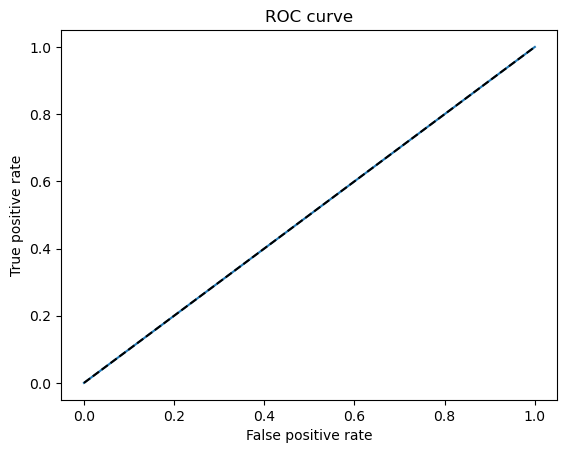

In [47]:
# load the best model
model.load_state_dict(torch.load('best_model_PT.pt'))

def predict(model, dataloader, device):
    model.eval()
    y_pred = []
    with torch.no_grad():
        for X, _ in dataloader:
            X = X.to(device)
            y_pred_batch = model(X)
            y_pred.append(y_pred_batch.cpu())
    y_pred = torch.cat(y_pred, dim=0)
    return y_pred

# evaluate the model on the test set
y_pred = predict(model, test_loader, device)
y_proba = F.softmax(y_pred, dim=1).detach().cpu().numpy()
y_pred = (y_proba[:, 0] > 0.5).astype('float32')
roc_auc = roc_auc_score(Y_test.numpy(), y_proba[:, 0])

# calculate and print the accuracy and ROC AUC score
accuracy = (y_pred == Y_test.numpy()).mean()
roc_auc = roc_auc_score(Y_test.numpy(), y_proba[:, 0])
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"ROC AUC: {roc_auc*100:.2f}%")

# plot the ROC curve
fpr, tpr, _ = roc_curve(Y_test.numpy(), y_proba[:, 0])
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.show()


In [58]:
print(y_pred.shape)
print(y_pred[78])

(30207,)
1.0


In [48]:
print(y_proba.shape)
print(y_proba)

(30207, 1)
[[1.]
 [1.]
 [1.]
 ...
 [1.]
 [1.]
 [1.]]
